[*********************100%***********************]  1 of 1 completed


Iniciando treino em: cpu
Epoch [10/50] | Train Loss: 0.000049 | Val Loss: 0.016685
Epoch [20/50] | Train Loss: 0.000030 | Val Loss: 0.005724
Epoch [30/50] | Train Loss: 0.000030 | Val Loss: 0.007616
Epoch [40/50] | Train Loss: 0.000021 | Val Loss: 0.007109
Epoch [50/50] | Train Loss: 0.000020 | Val Loss: 0.009064


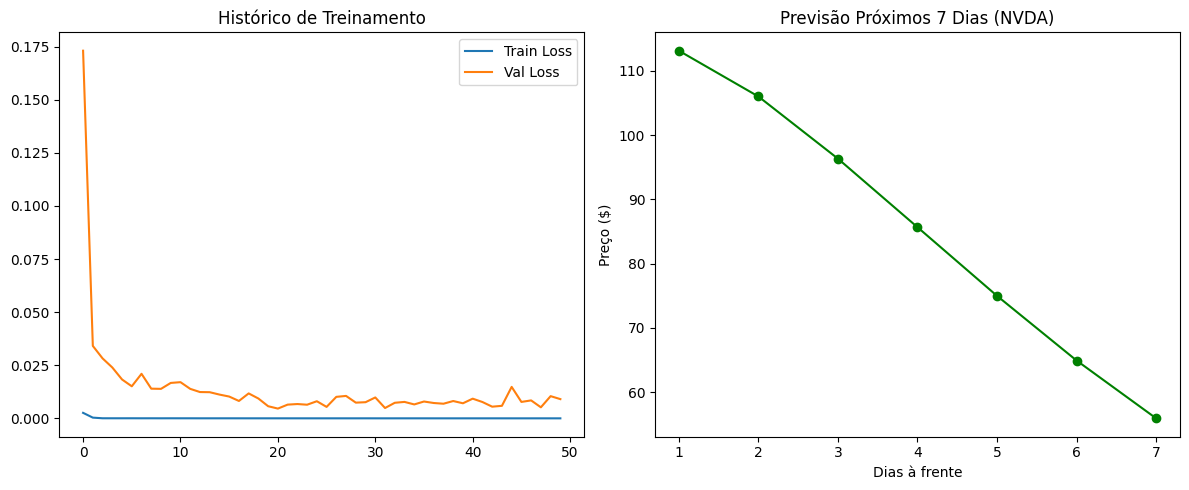

Preços previstos para os próximos 7 dias:
Dia 1: $113.16
Dia 2: $106.03
Dia 3: $96.34
Dia 4: $85.67
Dia 5: $74.98
Dia 6: $64.91
Dia 7: $55.90


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# 1. Configurações e Coleta de Dados
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
target_stock = 'NVDA'

# auto_adjust=True evita o FutureWarning e mantém os dados consistentes
df = yf.download(target_stock, start="2015-01-01", end="2025-01-01", auto_adjust=True)
data = df[['Close']].values

# ==========================================
# 2. Pré-processamento
# ==========================================
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 60
X, y = create_sequences(scaled_data, seq_length)

# Split Treino/Teste (80/20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Preparação dos DataLoaders
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                              torch.tensor(y_train, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                             torch.tensor(y_test, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ==========================================
# 3. Arquitetura do Modelo LSTM
# ==========================================
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        out, _ = self.lstm(x)
        # Pegamos apenas o último output da sequência: out[:, -1, :]
        out = self.fc(out[:, -1, :])
        return out

model = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# 4. Loop de Treinamento
# ==========================================
epochs = 50
train_losses, val_losses = [], []

print(f"Iniciando treino em: {device}")

for epoch in range(epochs):
    model.train()
    batch_losses = []
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    # Validação em cada época
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for val_X, val_y in test_loader:
            val_X, val_y = val_X.to(device), val_y.to(device)
            preds = model(val_X)
            val_loss += criterion(preds, val_y).item()

    train_losses.append(np.mean(batch_losses))
    val_losses.append(val_loss/len(test_loader))

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {train_losses[-1]:.6f} | Val Loss: {val_losses[-1]:.6f}')

# ==========================================
# 5. Previsão Futura (Correção de Dimensões)
# ==========================================
model.eval()
n_future = 7
# Pegamos a última janela de 60 dias conhecidos
last_sequence = scaled_data[-seq_length:]
current_input = torch.tensor(last_sequence, dtype=torch.float32).unsqueeze(0).to(device)

future_preds = []
for i in range(n_future):
    with torch.no_grad():
        # A saída 'pred' tem shape [1, 1]
        pred = model(current_input)
        future_preds.append(pred.item())

        # Correção aqui: Transformamos [1, 1] em [1, 1, 1] para concatenar com a janela
        new_step = pred.unsqueeze(2)

        # Removemos o primeiro item (o mais antigo) e adicionamos a nova previsão no final
        current_input = torch.cat((current_input[:, 1:, :], new_step), dim=1)

# Inverter o escalonamento para voltar aos preços reais
future_prices = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1))

# ==========================================
# 6. Resultados e Gráficos
# ==========================================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Histórico de Treinamento')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, n_future+1), future_prices, marker='o', color='green')
plt.title(f'Previsão Próximos {n_future} Dias ({target_stock})')
plt.xlabel('Dias à frente')
plt.ylabel('Preço ($)')
plt.tight_layout()
plt.show()

print(f"Preços previstos para os próximos {n_future} dias:")
for i, price in enumerate(future_prices, 1):
    print(f"Dia {i}: ${price[0]:.2f}")